# Marconi wave time series: pick a holdback interval
csherwood@usgs.gov, 2026-09-25, generated with Sonnet 5

Plots H and T for every image in the training CSV against time, so a contiguous block can be chosen to hold back for an unbiased skill assessment (a random split leaks information because consecutive hourly images are strongly autocorrelated). Re-run the last cell after adjusting `HOLD_START`/`HOLD_END` to see the shaded candidate interval, then carry those two values into the training notebook.

In [1]:
# csherwood@usgs.gov, 2026-09-25, generated with Sonnet 5
CSV_PATH = r"F:\crs\proj\2026_owg\Marconi-Training-Oblique-cam2-snap.csv"

# candidate holdback interval - set after looking at the plot below, then re-run
HOLD_START = "2025-02-15"
HOLD_END   = "2025-03-01"

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(CSV_PATH)
df["epoch"] = df["id"].map(lambda x: int(x.split(".")[0]))
df["time"] = pd.to_datetime(df["epoch"], unit="s", utc=True)
df = df.sort_values("time").reset_index(drop=True)
print(df.shape, df["time"].min(), "to", df["time"].max())
df.head()

(1429, 5) 2024-12-20 17:00:00+00:00 to 2025-03-10 15:00:00+00:00


,id,H,T,epoch,time
0,1734714000.Fri.Dec.20_17_00_00.GMT.2024.CACO03...,1.71,5.36,1734714000,2024-12-20 17:00:00+00:00
1,1734715800.Fri.Dec.20_17_30_00.GMT.2024.CACO03...,1.79,5.48,1734715800,2024-12-20 17:30:00+00:00
2,1734717600.Fri.Dec.20_18_00_00.GMT.2024.CACO03...,1.87,5.59,1734717600,2024-12-20 18:00:00+00:00
3,1734719400.Fri.Dec.20_18_30_00.GMT.2024.CACO03...,1.84,5.72,1734719400,2024-12-20 18:30:00+00:00
4,1734721200.Fri.Dec.20_19_00_00.GMT.2024.CACO03...,1.80,5.85,1734721200,2024-12-20 19:00:00+00:00


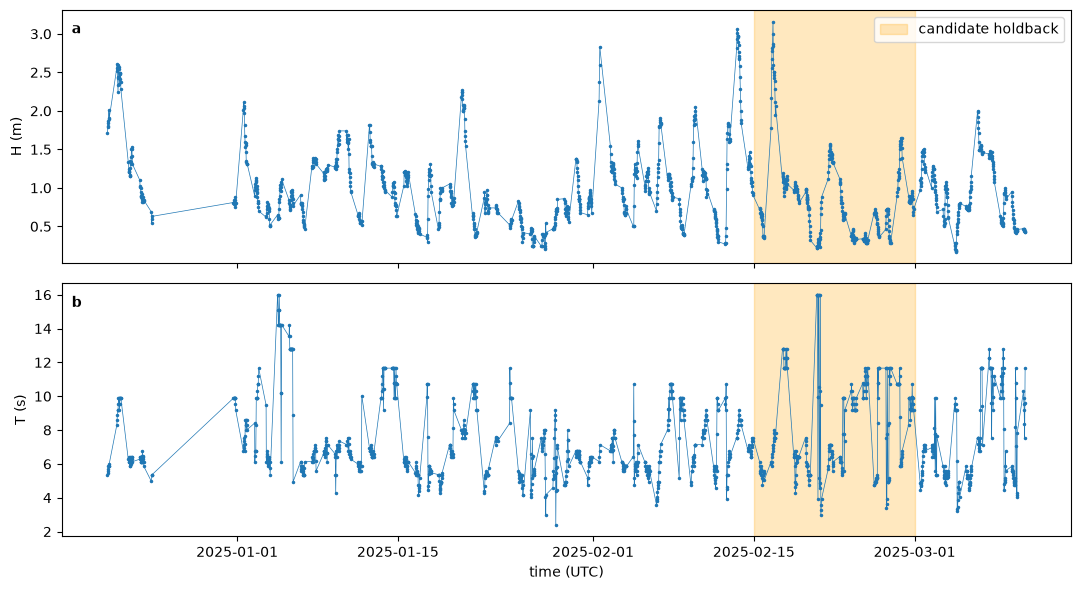

In [3]:
fig, axs = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
labels = ["a", "b"]
cols = [("H", "H (m)"), ("T", "T (s)")]
for ax, (col, ylab), label in zip(axs, cols, labels):
    ax.plot(df["time"], df[col], ".-", ms=3, lw=0.5)
    ax.set_ylabel(ylab)
    ax.text(0.01, 0.95, label, transform=ax.transAxes, ha="left", va="top", fontweight="bold")
    if HOLD_START and HOLD_END:
        ax.axvspan(pd.Timestamp(HOLD_START, tz="UTC"), pd.Timestamp(HOLD_END, tz="UTC"),
                    color="orange", alpha=0.25, label="candidate holdback")
axs[-1].set_xlabel("time (UTC)")
if HOLD_START and HOLD_END:
    axs[0].legend(loc="upper right")
fig.tight_layout()

Look for a block that (a) spans a reasonable range of sea states, not just calm weather, (b) is long enough to matter (a few weeks is typical for an hourly record like this), and (c) sits fully inside the record so the model still trains on data before and after it. Set `HOLD_START`/`HOLD_END` above and re-run the plot cell to check the shading before moving on to the training notebook.